# Solutions · 08 · Raoult's law and flash calculations

Worked solutions to the exercises of [notebook 08](../notebooks/08_raoults_law_and_flash.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engthermo import vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

Draw the P-x-y diagram of benzene-toluene at 90 degC. Read off the bubble and dew pressures of an equimolar liquid.

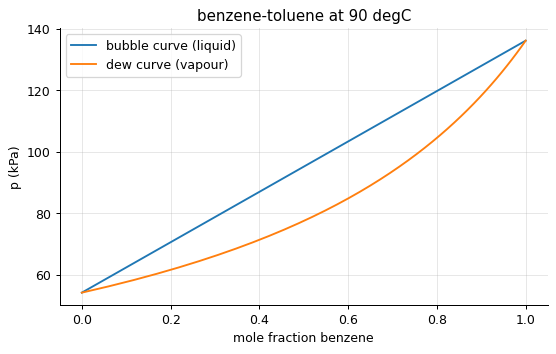

equimolar liquid: bubble pressure 95.2 kPa (vapour y = 0.715); equimolar vapour: dew pressure 77.5 kPa (liquid x = 0.285)


In [2]:
T = 90 + 273.15
d = vle.Pxy(["benzene", "toluene"], T, n=41)
plt.plot(d["x1"], d["p"] / 1e3, label="bubble curve (liquid)"); plt.plot(d["y1"], d["p"] / 1e3, label="dew curve (vapour)")
plt.xlabel("mole fraction benzene"); plt.ylabel("p (kPa)"); plt.title("benzene-toluene at 90 degC"); plt.legend(); plt.show()
bub, dew = vle.bubble_P(["benzene", "toluene"], [0.5, 0.5], T), vle.dew_P(["benzene", "toluene"], [0.5, 0.5], T)
print(f"equimolar liquid: bubble pressure {bub['p']/1e3:.1f} kPa (vapour y = {bub['y'][0]:.3f}); equimolar vapour: dew pressure {dew['p']/1e3:.1f} kPa (liquid x = {dew['x'][0]:.3f})")

On the P-x-y diagram of an ideal mixture the bubble curve is a straight line (Raoult's law is linear in x),
the dew curve a hyperbola. Reducing the pressure at constant temperature boils the liquid at the bubble
pressure and vaporises it completely at the dew pressure - a flash by pressure reduction, the counterpart of
the T-x-y reading.

## Exercise 2

A liquefied petroleum gas is 40 % propane and 60 % n-butane (mole). At 20 degC, what is the pressure in a storage vessel, and what is the composition of the vapour above the liquid? How does the vapour composition change as the vessel empties (assume the liquid becomes progressively richer in butane)?

In [3]:
T = 293.15
for x_p in (0.4, 0.3, 0.2, 0.1):
    r = vle.bubble_P(["propane", "n-butane"], [x_p, 1 - x_p], T)
    print(f"liquid {x_p:.0%} propane: vessel pressure {r['p']/1e5:.2f} bar, vapour {r['y'][0]:.0%} propane")

liquid 40% propane: vessel pressure 4.60 bar, vapour 73% propane
liquid 30% propane: vessel pressure 3.97 bar, vapour 63% propane
liquid 20% propane: vessel pressure 3.34 bar, vapour 50% propane
liquid 10% propane: vessel pressure 2.71 bar, vapour 31% propane


The vapour drawn off is much richer in propane than the liquid, so as the vessel empties the remaining liquid
becomes butane-rich and the pressure falls - from over 4 bar to under 3. LPG appliances see a gas whose
composition and pressure drift over the life of a cylinder; regulators and burner design allow for it.

## Exercise 3

**Implement it yourself:** write a bubble-temperature solver from scratch (Raoult's law, Antoine vapour pressures, `brentq` on the sum of $y_i$ minus 1) and reproduce the T-x-y diagram.

In [4]:
def bubble_T(comps, x, p):
    f = lambda T: sum(xi * vapor.antoine_psat(c, T) for c, xi in zip(comps, x)) / p - 1
    return optimize.brentq(f, 250.0, 450.0)
xs = np.linspace(0, 1, 21)
T_hand = [bubble_T(["benzene", "toluene"], [x, 1 - x], 101325.0) for x in xs]
lib = vle.Txy(["benzene", "toluene"], 101325.0, n=21)
print("agrees with the library to within 1e-9 K:", bool(np.max(np.abs(np.array(T_hand) - lib["T"])) < 1e-9))

agrees with the library to within 1e-9 K: True


The bubble-temperature condition is simply $\sum x_ip_i^{sat}(T)/p = 1$, monotonic in T, and a bracketed root
finder solves it in a few lines - the same code the library runs.